Cài đặt svgling để trình bày hình ảnh trên colab

In [ ]:
!pip install svgling &>> /dev/null

Khai báo trình bày kết quả vẽ từ python trên colab

In [ ]:
from IPython.display import display

**I - NLTK CORPUS**

NLTK corpus là tập hợp các ngữ liệu thử nghiệm tương đối nhỏ được trích một phần từ các ngữ liệu được sử dụng trong huấn luyện và đánh giá kết quả của một số bài toán trong NLP.

Khai báo sử dụng treebank trong NLTK corpus

In [ ]:
import nltk
from nltk.corpus import treebank
nltk.download('treebank')

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.


True

Sử dụng ngữ liệu phân tích cú pháp:


In [ ]:
parsedsents = treebank.parsed_sents()


***2) CẤU TRÚC CỦA NGỮ LIỆU GÁN NHÃN***

- Là một tập hợp các câu đã được gán nhãn từ loại
- Mỗi câu là một tập hợp các từ đã được gán nhãn
- Mỗi từ được gán nhãn là một bộ (word, tag)

In [ ]:
print(parsedsents[0])

(S
  (NP-SBJ
    (NP (NNP Pierre) (NNP Vinken))
    (, ,)
    (ADJP (NP (CD 61) (NNS years)) (JJ old))
    (, ,))
  (VP
    (MD will)
    (VP
      (VB join)
      (NP (DT the) (NN board))
      (PP-CLR (IN as) (NP (DT a) (JJ nonexecutive) (NN director)))
      (NP-TMP (NNP Nov.) (CD 29))))
  (. .))


***II - PHÂN TÍCH CÚ PHÁP***

***1) VĂN PHẠM CFG***

- Lớp quản lý văn phạm CFG




In [ ]:
from nltk.grammar import CFG

- Lớp phân tích cú pháp topdown



In [ ]:
from nltk.parse import RecursiveDescentParser

- Lớp phân tích cú pháp theo thuật toán Earley



In [ ]:
from nltk.parse import EarleyChartParser

***2) KHỞI TẠO VĂN PHẠM***

In [ ]:
cfg = CFG.fromstring("""
S -> NP VP
VP -> VB
VP -> VB NP PP
VP -> VB NP
NP -> DT NN
NP -> NP PP
PP -> IN NN
VB -> 'thấy'
NN -> 'bà' | 'người' | 'nhà'
DT -> 'một'
IN -> 'trong'
""")

***3) PHÂN TÍCH CÚ PHÁP***

Tạo đối tượng phân tích cú pháp

In [ ]:
cfgparser = EarleyChartParser(cfg)

Phân tích câu và hiển thị kết quả

(S
  (NP (DT một) (NN bà))
  (VP
    (VB thấy)
    (NP (NP (DT một) (NN người)) (PP (IN trong) (NN nhà)))))


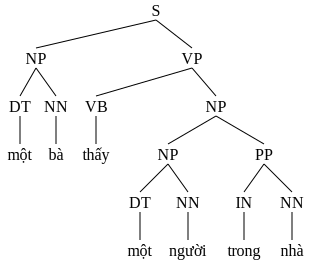

(S
  (NP (DT một) (NN bà))
  (VP (VB thấy) (NP (DT một) (NN người)) (PP (IN trong) (NN nhà))))


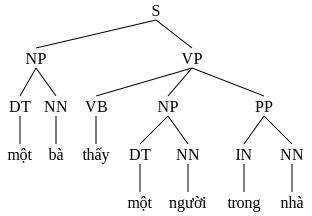

In [ ]:
s = 'một bà thấy một người trong nhà'.split()
for tree in cfgparser.parse(s):
  print(tree.pformat())
  display(tree)


***4) CÁC THAO TÁC VỚI CÂY CÚ PHÁP***

***TẠO CÂY CÚ PHÁP TỪ CHUỖI***

Khai báo:

In [ ]:
from nltk.tree import Tree

Tạo cây cú pháp từ dạng văn bản (dạng dấu ngoặc)

In [ ]:
tree = Tree.fromstring("""
(S
	(NP (DT một) (NN bà))
	(VP
		(VB thấy)
		(NP (NP (DT một) (NN người)) (PP (IN trong) (NN nhà)))))
""")



***CÁC THAO TÁC***

Trích các luật sản sinh được sử dụng trong cây cú pháp:

In [ ]:
tree.productions()

[S -> NP VP,
 NP -> DT NN,
 DT -> 'một',
 NN -> 'bà',
 VP -> VB NP,
 VB -> 'thấy',
 NP -> NP PP,
 NP -> DT NN,
 DT -> 'một',
 NN -> 'người',
 PP -> IN NN,
 IN -> 'trong',
 NN -> 'nhà']

Xét vế trái hoặc vế phải của một luật sản sinh:



In [ ]:
lhs = tree.productions()[0].lhs()
rhs = tree.productions()[0].rhs()
print(lhs)
print(rhs)

S
(NP, VP)


Lấy danh sách cây con:


In [ ]:
list(tree.subtrees())


[Tree('S', [Tree('NP', [Tree('DT', ['một']), Tree('NN', ['bà'])]), Tree('VP', [Tree('VB', ['thấy']), Tree('NP', [Tree('NP', [Tree('DT', ['một']), Tree('NN', ['người'])]), Tree('PP', [Tree('IN', ['trong']), Tree('NN', ['nhà'])])])])]),
 Tree('NP', [Tree('DT', ['một']), Tree('NN', ['bà'])]),
 Tree('DT', ['một']),
 Tree('NN', ['bà']),
 Tree('VP', [Tree('VB', ['thấy']), Tree('NP', [Tree('NP', [Tree('DT', ['một']), Tree('NN', ['người'])]), Tree('PP', [Tree('IN', ['trong']), Tree('NN', ['nhà'])])])]),
 Tree('VB', ['thấy']),
 Tree('NP', [Tree('NP', [Tree('DT', ['một']), Tree('NN', ['người'])]), Tree('PP', [Tree('IN', ['trong']), Tree('NN', ['nhà'])])]),
 Tree('NP', [Tree('DT', ['một']), Tree('NN', ['người'])]),
 Tree('DT', ['một']),
 Tree('NN', ['người']),
 Tree('PP', [Tree('IN', ['trong']), Tree('NN', ['nhà'])]),
 Tree('IN', ['trong']),
 Tree('NN', ['nhà'])]

Lấy các nút lá của cây:


In [ ]:
tree.leaves()


['một', 'bà', 'thấy', 'một', 'người', 'trong', 'nhà']

***5) VĂN PHẠM PCFG***

***KHAI BÁO***

- Lớp quản lý văn phạm CFG



In [ ]:
from nltk.grammar import PCFG

- Lớp phân tích cú pháp topdown



In [ ]:
from nltk.parse.pchart import InsideChartParser

- Lớp phân tích cú pháp theo thuật toán Viterbi



In [ ]:
from nltk.parse import ViterbiParser

***TẠO VĂN PHẠM PCFG***

In [ ]:
cfg = PCFG.fromstring("""
S -> NP VP [1]
VP -> VB [0.3]
VP -> VB NP PP [0.5]
VP -> VB NP [0.2]
NP -> DT NN [0.7]
NP -> NP PP [0.3]
PP -> IN NN [1]
VB -> 'thấy' [1]
NN -> 'bà' [0.3]| 'người' [0.3]| 'nhà' [0.4]
DT -> 'một' [1]
IN -> 'trong' [1]
""")


Tạo đối tượng phân tích cú pháp, dùng lớp InsideChartParser hoặc ViterbiParser



In [ ]:
INSparser = InsideChartParser(cfg)
VTBparser = ViterbiParser(cfg)


Phân tích cú pháp và hiển thị kết quả gồm cây cú pháp và xác suất của nó:


0.00882
(S
  (NP (DT một) (NN bà))
  (VP (VB thấy) (NP (DT một) (NN người)) (PP (IN trong) (NN nhà))))


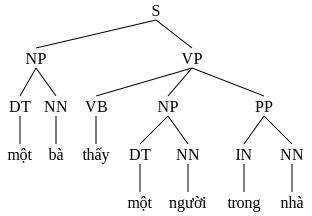

In [ ]:
s = 'một bà thấy một người trong nhà'.split()
for tree in VTBparser.parse(s):
  print(tree.prob())
  print(tree.pformat())
  display(tree)
